# IKENGA RESEARCH SANDBOX

Edit algorithms in `sandbox/algorithms/`, not in `src/`.
All data access uses live database and candle store.

In [1]:
# ============================================================
# CELL 1: SETUP AND IMPORTS
# ============================================================
import sys
from pathlib import Path

# Add project root and sandbox to path
ROOT = Path("..").resolve()
SANDBOX = ROOT / "sandbox" / "algorithms"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SANDBOX) not in sys.path:
    sys.path.insert(0, str(SANDBOX))

# Import FROM SANDBOX — these override live src/ imports
from trend_id import identify_trend, compute_internal_structure
from choch_zone import get_active_choch_zone
from structure_levels import compute_all_structure_levels
from filter_defaults import SCAN_AND_ANALYSIS_FILTER_DEFAULTS

# DB and candle access (always from live)
from src.db.session import SessionLocal
from src.db.models import MonitoredSetup
from src.cache.candle_store import get_candles

print("✓ Sandbox imports OK")
print(f"✓ Algorithm source: {SANDBOX}")

✓ Sandbox imports OK
✓ Algorithm source: C:\Users\vokor\Documents\Projects\chronos-ai\sandbox\algorithms


In [2]:
# ============================================================
# CELL 2: CONFIGURATION - edit these values
# ============================================================

# Symbol - must be in top 50 monitored
SYMBOL = "BOOM300N"

# Timeframes to analyse
TIMEFRAMES = ["1d", "1w", "15m"]

# Drawing groups to show
SHOW_GLOBAL    = True   # global trend legs + BOS + CHoCH zones
SHOW_PRIME     = True   # prime impulse internal structure
SHOW_WALKER    = True   # walker depth zones
SHOW_CANDIDATE = True   # candidate impulse legs
SHOW_RAW_STRUCTURE = False  # draw the original pre-clean structure faintly underneath
SHOW_FAKE_IMPULSES = False   # highlight impulses classified as false breaks

# --- Swing detection ---
MIN_SWING_CANDLES      = 3      # default 3; lower = tighter pivots, more swings detected
TREND_CONFIRMATION_PCT = 0.03   # default 0.03; lower = fewer range classifications

# Walker-specific trend threshold for D1/depth internal structure.
# 0.005 means a 0.5% minimum move to classify as trend.
WALKER_TREND_CONFIRMATION_PCT = 0.002

# --- Sequence / BOS controls ---
IMPULSE_SELECTION_MODE = "largest_score"  # "largest_score" = deepest pullback wins; "earliest_valid" = first passing candidate in time
ENFORCE_IMPULSE_BOS    = True             # impulse #2+ must break prior impulse structure
MIN_BOS_BREAK_RATIO    = 0.0              # minimum extra break distance as fraction of window range (0 = strict touch is enough)
IMPULSE_TOP_N          = 2                # 1 = default (one leg per phase); 2 = take 2 top-scored candidates, insert intermediate retracement between them
FALSE_BREAK_RETRACE_RATIO = 0.70         # if the retracement after a breaking impulse is >= this fraction of that impulse, classify the BOS as false
APPLY_FALSE_BREAK_CLEANER = True         # absorb false-breaking impulses back into the prior valid impulse
FALSE_IMPULSE_MAX_ITERATIONS = 20        # safety cap for repeated collapse passes

# --- Candidate lower-timeframe analysis ---
CANDIDATE_ANALYSIS_TIMEFRAMES = ["1h", "15m"]
CANDIDATE_SOURCE_SELECTION = "least_legs"  # options: least_legs, most_legs
CANDIDATE_DISPLAY_TIMEFRAME = "15m"        # candidate panel always uses 15m candles for display

# --- Trend filters (sandbox-local overrides) ---
# Filter 1: parent-relative impulse size
USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO   = 0.02

# Filter 2: momentum decay
USE_MOMENTUM_FILTER = True
MIN_MOMENTUM_RATIO  = 0.01

# Filter 3: impulse dominance over retracement
USE_DOMINANCE_FILTER = True
MIN_DOMINANCE_RATIO  = 0.05

# Build filter config from shared defaults, then override with sandbox variables
FILTER_CONFIG = dict(SCAN_AND_ANALYSIS_FILTER_DEFAULTS)
FILTER_CONFIG.update({
    "min_swing_candles": MIN_SWING_CANDLES,
    "trend_confirmation_pct": TREND_CONFIRMATION_PCT,
    "impulse_selection_mode": IMPULSE_SELECTION_MODE,
    "enforce_impulse_bos": ENFORCE_IMPULSE_BOS,
    "min_bos_break_ratio": MIN_BOS_BREAK_RATIO,
    "impulse_top_n": IMPULSE_TOP_N,
    "use_parent_relative_filter": USE_PARENT_RELATIVE_FILTER,
    "min_impulse_parent_ratio": MIN_IMPULSE_PARENT_RATIO,
    "use_momentum_filter": USE_MOMENTUM_FILTER,
    "min_momentum_ratio": MIN_MOMENTUM_RATIO,
    "use_dominance_filter": USE_DOMINANCE_FILTER,
    "min_dominance_ratio": MIN_DOMINANCE_RATIO,
})

print(f"Symbol: {SYMBOL}")
print(f"Timeframes: {TIMEFRAMES}")
print(
    "Show: "
    f"global={SHOW_GLOBAL} "
    f"walker={SHOW_WALKER} "
    f"raw={SHOW_RAW_STRUCTURE} "
    f"fake_impulses={SHOW_FAKE_IMPULSES}"
)
print(
    "Swing: "
    f"min_swing_candles={MIN_SWING_CANDLES} "
    f"trend_confirmation_pct={TREND_CONFIRMATION_PCT}"
)
print(
    "Walker: "
    f"walker_trend_confirmation_pct={WALKER_TREND_CONFIRMATION_PCT}"
)
print(
    "Sequence: "
    f"mode={IMPULSE_SELECTION_MODE} "
    f"top_n={IMPULSE_TOP_N} "
    f"enforce_bos={ENFORCE_IMPULSE_BOS} "
    f"min_bos_break_ratio={MIN_BOS_BREAK_RATIO}"
)
print(
    "BOS quality: "
    f"false_break_retrace_ratio={FALSE_BREAK_RETRACE_RATIO} "
    f"cleaner={APPLY_FALSE_BREAK_CLEANER} "
    f"max_iters={FALSE_IMPULSE_MAX_ITERATIONS}"
)
print(
    "Candidate: "
    f"analysis_tfs={CANDIDATE_ANALYSIS_TIMEFRAMES} "
    f"selection={CANDIDATE_SOURCE_SELECTION} "
    f"display_tf={CANDIDATE_DISPLAY_TIMEFRAME}"
)
print(
    "Filters:",
    f"parent={USE_PARENT_RELATIVE_FILTER}/{MIN_IMPULSE_PARENT_RATIO}",
    f"momentum={USE_MOMENTUM_FILTER}/{MIN_MOMENTUM_RATIO}",
    f"dominance={USE_DOMINANCE_FILTER}/{MIN_DOMINANCE_RATIO}",
)

Symbol: BOOM300N
Timeframes: ['1d', '1w', '15m']
Show: global=True walker=True raw=False fake_impulses=False
Swing: min_swing_candles=3 trend_confirmation_pct=0.03
Walker: walker_trend_confirmation_pct=0.002
Sequence: mode=largest_score top_n=2 enforce_bos=True min_bos_break_ratio=0.0
BOS quality: false_break_retrace_ratio=0.7 cleaner=True max_iters=20
Candidate: analysis_tfs=['1h', '15m'] selection=least_legs display_tf=15m
Filters: parent=True/0.02 momentum=True/0.01 dominance=True/0.05


In [3]:
# ============================================================
# CELL 3: DATA LOADING
# ============================================================
db = SessionLocal()

# Verify symbol is monitored
monitored = sorted(list(set(
    r[0] for r in
    db.query(MonitoredSetup.symbol).all()
)))
if SYMBOL not in monitored:
    print(f"⚠ {SYMBOL} not in monitored. Available: {monitored[:5]}...")
else:
    print(f"✓ {SYMBOL} is monitored")

# Load candles for each timeframe
candle_data = {}
for tf in TIMEFRAMES:
    try:
        candles = get_candles(SYMBOL, tf, db)
        candle_data[tf] = candles
        print(f"✓ {tf}: {len(candles)} candles "
              f"({candles[0].timestamp.date()} → {candles[-1].timestamp.date()})")
    except Exception as e:
        print(f"✗ {tf}: {str(e)[:50]}")

print(f"\nReady. {len(candle_data)} timeframes loaded.")

✓ BOOM300N is monitored
✓ 1d: 470 candles (2025-04-03 → 2026-04-23)


Hydrating Deriv active symbols cache
Hydrating Deriv active symbols cache


✓ 1w: 460 candles (2025-04-03 → 2026-04-22)
✓ 15m: 18815 candles (2025-10-09 → 2026-04-23)

Ready. 3 timeframes loaded.


In [4]:
# ============================================================
# CELL 4: RUN ANALYSIS (uses sandbox/algorithms/)
# ============================================================
import sys
import copy
import importlib
from pathlib import Path

ROOT = Path("..").resolve()
SANDBOX = ROOT / "sandbox" / "algorithms"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SANDBOX) not in sys.path:
    sys.path.insert(0, str(SANDBOX))

# Force reload so edits to sandbox files take effect without kernel restart
import trend_id as _trend_id_mod
importlib.reload(_trend_id_mod)
from trend_id import identify_trend, compute_internal_structure

import structural_walker as _sw_mod
importlib.reload(_sw_mod)
from structural_walker import walk_structure

import choch_zone as _cz_mod
importlib.reload(_cz_mod)
from choch_zone import compute_choch_zone

import structure_levels as _sl_mod
importlib.reload(_sl_mod)
from structure_levels import (
    annotate_internal_bos_classifications,
    classify_bos_events,
    collapse_false_break_impulses,
    compute_all_structure_levels,
    extract_false_break_impulses,
)


def _status_counts(events):
    counts = {"true": 0, "false": 0, "pending": 0, "invalid": 0}
    for event in events:
        status = event.get("status", "pending")
        if status not in counts:
            counts[status] = 0
        counts[status] += 1
    return counts


def _last_confirmed_leg(legs, leg_type):
    for leg in reversed(legs or []):
        if leg.get("type") == leg_type and leg.get("confirmed"):
            return leg
    return None


def _largest_confirmed_impulse(legs):
    best = None
    best_move = -1.0
    for leg in legs or []:
        if leg.get("type") != "impulse" or not leg.get("confirmed"):
            continue
        if leg.get("start_price") is None or leg.get("end_price") is None:
            continue
        move = abs(float(leg["end_price"]) - float(leg["start_price"]))
        if move > best_move:
            best_move = move
            best = leg
    return best


def _confirmed_leg_count(result):
    return sum(1 for leg in (result or {}).get("legs", []) if leg.get("confirmed"))


def _ensure_timeframe_loaded(symbol, timeframe, db_session, candle_cache):
    if timeframe not in candle_cache:
        candle_cache[timeframe] = get_candles(symbol, timeframe, db_session)
    return candle_cache[timeframe]


def _slice_candles_by_time(candles, start_ts, end_ts):
    return [candle for candle in candles if start_ts <= candle.timestamp <= end_ts]


def _analyze_structure_window(candles, symbol):
    raw_result = identify_trend(candles, **FILTER_CONFIG)
    compute_internal_structure(candles, raw_result["legs"], **FILTER_CONFIG)
    annotate_internal_bos_classifications(
        raw_result["legs"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )

    raw_levels = compute_all_structure_levels(
        candles,
        raw_result["legs"],
        raw_result["trend"],
    )
    raw_global_bos_levels = raw_levels.get("bos_levels", [])
    raw_global_bos_classifications = classify_bos_events(
        raw_result["legs"],
        raw_result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )
    raw_global_bos_by_start_index = {
        event["source_impulse_end_index"]: event
        for event in raw_global_bos_classifications
    }
    for bos in raw_global_bos_levels:
        event = raw_global_bos_by_start_index.get(bos.get("start_index"))
        bos["classification"] = event.get("status") if event else "pending"
        bos["retracement_ratio"] = event.get("retracement_ratio") if event else None

    raw_false_impulse_legs = extract_false_break_impulses(
        raw_result["legs"],
        raw_result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )
    raw_false_impulses = [
        {
            "breaking_impulse": copy.deepcopy(leg),
            "event": copy.deepcopy(leg.get("false_break_event") or {}),
        }
        for leg in raw_false_impulse_legs
    ]

    cleanup = {
        "legs": copy.deepcopy(raw_result["legs"]),
        "false_impulses": copy.deepcopy(raw_false_impulses),
        "history": [],
        "iterations": 0,
        "classifications": copy.deepcopy(raw_global_bos_classifications),
        "internal_collapses": 0,
    }
    if APPLY_FALSE_BREAK_CLEANER:
        cleanup = collapse_false_break_impulses(
            raw_result["legs"],
            raw_result["trend"],
            false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
            max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
        )

    result = copy.deepcopy(raw_result)
    result["legs"] = copy.deepcopy(cleanup.get("legs", raw_result["legs"]))
    compute_internal_structure(candles, result["legs"], **FILTER_CONFIG)

    if APPLY_FALSE_BREAK_CLEANER:
        internal_collapses = 0
        for leg in result["legs"]:
            if leg.get("type") == "impulse" and leg.get("confirmed"):
                internal = leg.get("internal_structure") or {}
                internal_legs = internal.get("legs", [])
                internal_trend = internal.get("trend")
                if internal_legs and internal_trend in {"up", "down"}:
                    internal_cleanup = collapse_false_break_impulses(
                        internal_legs,
                        internal_trend,
                        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
                        max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
                    )
                    internal["legs"] = internal_cleanup.get("legs", internal_legs)
                    leg["internal_false_impulses"] = internal_cleanup.get("false_impulses", [])
                    leg["internal_collapse_iterations"] = internal_cleanup.get("iterations", 0)
                    internal_collapses += internal_cleanup.get("iterations", 0)
        cleanup["internal_collapses"] = internal_collapses

    annotate_internal_bos_classifications(
        result["legs"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )

    levels = compute_all_structure_levels(candles, result["legs"], result["trend"])
    global_bos_levels = levels.get("bos_levels", [])
    global_bos_classifications = classify_bos_events(
        result["legs"],
        result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )
    global_bos_by_start_index = {
        event["source_impulse_end_index"]: event
        for event in global_bos_classifications
    }
    for bos in global_bos_levels:
        event = global_bos_by_start_index.get(bos.get("start_index"))
        bos["classification"] = event.get("status") if event else "pending"
        bos["retracement_ratio"] = event.get("retracement_ratio") if event else None

    global_choch_zone = compute_choch_zone(result["legs"], result["trend"])

    walker_tf_selection_mode = "longest_first_impulse"
    walker_state = walk_structure(
        candles,
        result,
        FILTER_CONFIG,
        max_depth=3,
        walker_trend_confirmation_pct=WALKER_TREND_CONFIRMATION_PCT,
        symbol=symbol,
        deepening_timeframes=["4h", "1h", "30m", "15m"],
        deepening_selection_mode=walker_tf_selection_mode,
        apply_false_break_cleaner=APPLY_FALSE_BREAK_CLEANER,
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
        false_break_max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
    )

    status_counts = _status_counts(global_bos_classifications)
    raw_status_counts = _status_counts(raw_global_bos_classifications)

    return {
        "candles": candles,
        "result": result,
        "raw_result": raw_result,
        "false_impulses": cleanup.get("false_impulses", raw_false_impulses),
        "false_break_cleanup": cleanup,
        "global_choch_zone": global_choch_zone,
        "global_bos_levels": global_bos_levels,
        "global_bos_classifications": global_bos_classifications,
        "global_bos_status_counts": status_counts,
        "raw_global_bos_levels": raw_global_bos_levels,
        "raw_global_bos_status_counts": raw_status_counts,
        "walker_state": walker_state,
    }


def _select_candidate_analysis(options, selection_mode):
    if not options:
        return None

    if selection_mode == "most_legs":
        return sorted(
            options,
            key=lambda item: (item["confirmed_legs"], -item["timeframe_rank"]),
            reverse=True,
        )[0]

    return sorted(
        options,
        key=lambda item: (item["confirmed_legs"], item["timeframe_rank"]),
    )[0]


def _compute_live_candidate(candles, active_result, symbol, db_session, candle_cache):
    trend = active_result.get("trend")
    if trend not in {"up", "down"} or not candles:
        return None

    last_retracement = _last_confirmed_leg(active_result.get("legs", []), "retracement")
    if not last_retracement:
        return None

    start_index = last_retracement.get("end_index")
    start_price = last_retracement.get("end_price")
    if start_index is None or start_price is None:
        return None

    start_index = int(start_index)
    start_price = float(start_price)
    if start_index < 0 or start_index >= len(candles) - 1:
        return None

    current_index = len(candles) - 1
    current_price = float(candles[current_index].close)
    moved_in_trend = current_price > start_price if trend == "up" else current_price < start_price
    if not moved_in_trend:
        return None

    candidate_segment = candles[start_index : current_index + 1]
    if len(candidate_segment) < 2:
        return None

    if trend == "up":
        extreme_price = max(float(candle.high) for candle in candidate_segment)
        extreme_local = next(i for i, candle in enumerate(candidate_segment) if float(candle.high) == extreme_price)
    else:
        extreme_price = min(float(candle.low) for candle in candidate_segment)
        extreme_local = next(i for i, candle in enumerate(candidate_segment) if float(candle.low) == extreme_price)

    extreme_index = start_index + extreme_local
    extreme_ts = candles[extreme_index].timestamp
    start_ts = candles[start_index].timestamp
    current_ts = candles[current_index].timestamp

    if extreme_index <= start_index:
        return None

    last_impulse = _last_confirmed_leg(active_result.get("legs", []), "impulse")
    structure_broken = None
    if last_impulse and last_impulse.get("end_price") is not None:
        ref_bos = float(last_impulse["end_price"])
        structure_broken = current_price > ref_bos if trend == "up" else current_price < ref_bos

    analysis_options = []
    for timeframe_rank, source_tf in enumerate(CANDIDATE_ANALYSIS_TIMEFRAMES):
        source_all = _ensure_timeframe_loaded(symbol, source_tf, db_session, candle_cache)
        source_slice = _slice_candles_by_time(source_all, start_ts, extreme_ts)
        if len(source_slice) < 10:
            continue
        source_analysis = _analyze_structure_window(source_slice, symbol)
        analysis_options.append({
            "timeframe": source_tf,
            "timeframe_rank": timeframe_rank,
            "confirmed_legs": _confirmed_leg_count(source_analysis["result"]),
            "analysis": source_analysis,
        })

    selected_analysis = _select_candidate_analysis(analysis_options, CANDIDATE_SOURCE_SELECTION)

    display_all = _ensure_timeframe_loaded(symbol, CANDIDATE_DISPLAY_TIMEFRAME, db_session, candle_cache)
    display_slice = _slice_candles_by_time(display_all, start_ts, current_ts)

    candidate = {
        "trend": trend,
        "start_index": start_index,
        "start_timestamp": start_ts,
        "start_price": start_price,
        "extreme_index": extreme_index,
        "extreme_timestamp": extreme_ts,
        "extreme_price": extreme_price,
        "current_index": current_index,
        "current_timestamp": current_ts,
        "current_price": current_price,
        "structure_broken": structure_broken,
        "display_timeframe": CANDIDATE_DISPLAY_TIMEFRAME,
        "display_candles": display_slice,
        "analysis_window_start_timestamp": start_ts,
        "analysis_window_end_timestamp": extreme_ts,
        "analysis_timeframes": [item["timeframe"] for item in analysis_options],
        "selected_source_tf": selected_analysis["timeframe"] if selected_analysis else None,
        "selected_source_leg_count": selected_analysis["confirmed_legs"] if selected_analysis else None,
        "selected_analysis": selected_analysis["analysis"] if selected_analysis else None,
    }
    return candidate


results = {}
candidate_plot = None

# Fresh DB session — Cell 3 connection may have timed out
from src.db.session import SessionLocal
db = SessionLocal()

for tf in TIMEFRAMES:
    if tf not in candle_data:
        print(f"skipping {tf}: no candles")
        continue

    candles = candle_data[tf]
    analysis = _analyze_structure_window(candles, SYMBOL)
    live_candidate = _compute_live_candidate(candles, analysis["result"], SYMBOL, db, candle_data)

    results[tf] = {
        **analysis,
        "candidate": live_candidate,
    }

    raw_result = analysis["raw_result"]
    result = analysis["result"]
    cleanup = analysis["false_break_cleanup"]
    walker_state = analysis["walker_state"]
    global_bos_levels = analysis["global_bos_levels"]
    status_counts = analysis["global_bos_status_counts"]

    raw_confirmed = sum(1 for leg in raw_result["legs"] if leg.get("confirmed"))
    active_confirmed = sum(1 for leg in result["legs"] if leg.get("confirmed"))
    total_internal_iters = sum(
        leg.get("internal_collapse_iterations", 0)
        for leg in result["legs"]
        if leg.get("type") == "impulse" and leg.get("confirmed")
    )
    depth = walker_state.get("max_depth_reached", 0) if walker_state else 0
    levels = (walker_state or {}).get("levels", [])
    d1 = next((lvl for lvl in levels if lvl.get("depth") == 1), {})
    candidate_state = "yes" if live_candidate else "no"
    candidate_break = live_candidate.get("structure_broken") if live_candidate else None
    candidate_source = live_candidate.get("selected_source_tf") if live_candidate else None
    candidate_extreme = live_candidate.get("extreme_price") if live_candidate else None
    print(
        f"{tf}: trend={result['trend']} legs={raw_confirmed}->{active_confirmed} "
        f"bos={len(global_bos_levels)} "
        f"T/F/P={status_counts.get('true', 0)}/"
        f"{status_counts.get('false', 0)}/"
        f"{status_counts.get('pending', 0)} "
        f"fake={len(results[tf]['false_impulses'])} "
        f"global_iters={cleanup.get('iterations', 0)} "
        f"internal_iters={total_internal_iters} "
        f"depth={depth} candidate={candidate_state} "
        f"candidate_source={candidate_source} "
        f"candidate_extreme={candidate_extreme} "
        f"candidate_broken={candidate_break} "
        f"walker_tcp={WALKER_TREND_CONFIRMATION_PCT} "
        f"d1_seed={d1.get('seed_tf_used', 'n/a')} "
        f"d1_internal={d1.get('internal_tf_used', 'n/a')}"
    )

candidate_parent_order = [
    tf for tf in TIMEFRAMES
    if tf != CANDIDATE_DISPLAY_TIMEFRAME
] + [tf for tf in TIMEFRAMES if tf == CANDIDATE_DISPLAY_TIMEFRAME]

for parent_tf in candidate_parent_order:
    parent_data = results.get(parent_tf)
    if parent_data and parent_data.get("candidate"):
        candidate_plot = {
            "parent_tf": parent_tf,
            "candidate": parent_data["candidate"],
        }
        break

if candidate_plot is not None:
    print(
        f"candidate panel source parent={candidate_plot['parent_tf']} "
        f"selected_tf={candidate_plot['candidate'].get('selected_source_tf')} "
        f"display_tf={candidate_plot['candidate'].get('display_timeframe')}"
    )
else:
    print("candidate panel source parent=n/a selected_tf=n/a display_tf=n/a")

Hydrating Deriv active symbols cache
Hydrating Deriv active symbols cache
Hydrating Deriv active symbols cache
Deriv history for 'BOOM300N' 15m is shallower than expected: got 2 candles, expected ~5760 (lookback_days=60.0). Returning available candles.
Deriv history for 'BOOM300N' 1d is shallower than expected: got 1 candles, expected ~2190 (lookback_days=2190.0). Returning available candles.
Deriv history for 'BOOM300N' 1d is shallower than expected: got 2 candles, expected ~2190 (lookback_days=2190.0). Returning available candles.
Deriv history for 'BOOM300N' 1h is shallower than expected: got 1 candles, expected ~8760 (lookback_days=365.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 

1d: trend=down legs=10->8 bos=4 T/F/P=3/0/1 fake=1 global_iters=1 internal_iters=1 depth=1 candidate=yes candidate_source=1h candidate_extreme=1160.167 candidate_broken=False walker_tcp=0.002 d1_seed=current d1_internal=current
1w: trend=down legs=10->10 bos=5 T/F/P=4/0/1 fake=0 global_iters=0 internal_iters=1 depth=1 candidate=no candidate_source=None candidate_extreme=None candidate_broken=None walker_tcp=0.002 d1_seed=current d1_internal=current


Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for 'BOOM300N' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning avai

15m: trend=down legs=6->6 bos=3 T/F/P=2/0/1 fake=0 global_iters=0 internal_iters=6 depth=3 candidate=yes candidate_source=1h candidate_extreme=1162.246 candidate_broken=False walker_tcp=0.002 d1_seed=current d1_internal=current
candidate panel source parent=1d selected_tf=1h display_tf=15m


BOOM300N 1d: walker source tf -> D1=seed:current/internal:current
BOOM300N 1w: walker source tf -> D1=seed:current/internal:current
BOOM300N candidate panel: parent=1d source_tf=1h display_tf=15m
Chart saved: BOOM300N_1d_1w_15m.png


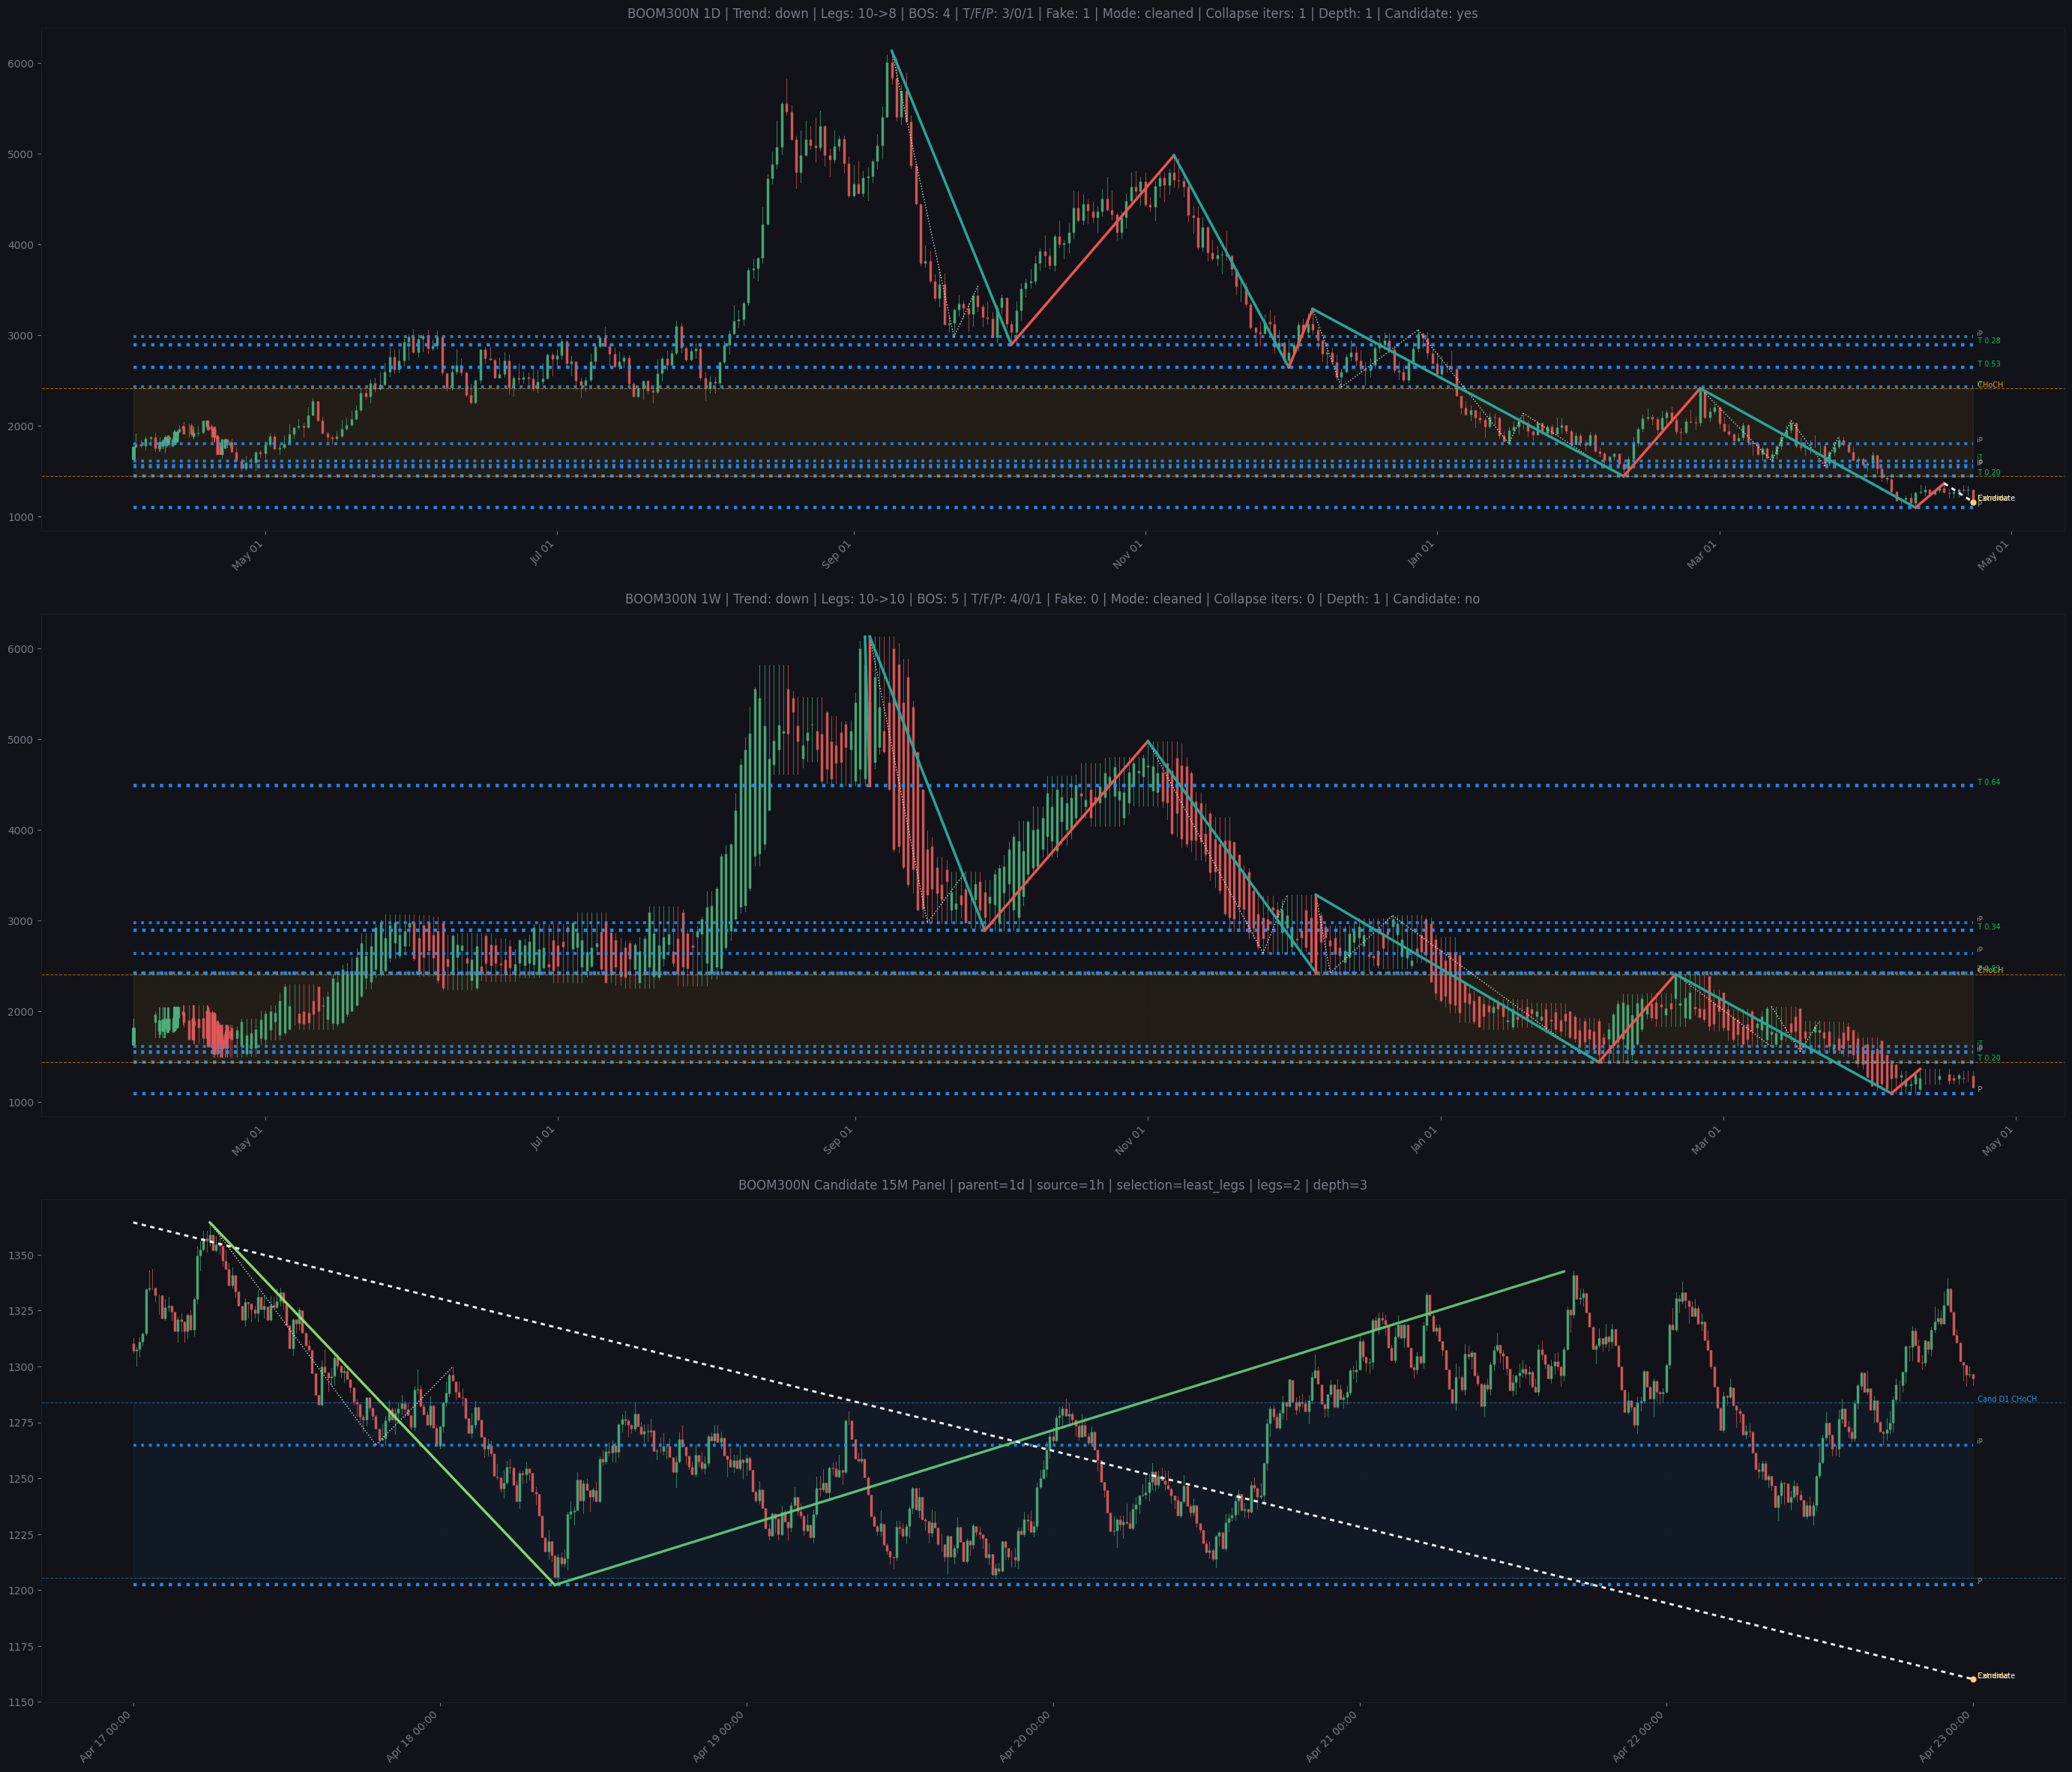

In [5]:
# ============================================================
# CELL 5: PLOTTING
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from structure_levels import compute_all_structure_levels

COLORS = {
    "bg":                 "#111318",
    "grid":               "#1C1E24",
    "text":               "#787B86",
    "candle_up":          "#4CAF7D",
    "candle_down":        "#E05A5A",
    "global_imp":         "#26A69A",
    "global_ret":         "#EF5350",
    "raw_imp":            "#4F7C78",
    "raw_ret":            "#8C4A4A",
    "prime_leg":          "#FFFFFF",
    "candidate_imp":      "#8EE36B",
    "candidate_ret":      "#5FCB7A",
    "candidate_line":     "#FFFFFF",
    "candidate_extreme":  "#FFD166",
    "fake_impulse":       "#FFD166",
    "amber":              "#F59E0B",
    "ichoch":             "#26A69A",
    "depth_1":            "#2196F3",
    "depth_2":            "#4CAF50",
    "depth_3":            "#9C27B0",
    "bos_true":           "#00C853",
    "bos_false":          "#D50000",
    "bos_pending":        "#9E9E9E",
    "bos_broken":         "#FFFFFF",
    "walker_first_move":  "#FFD166",
}

DEPTH_COLORS = {
    1: COLORS["depth_1"],
    2: COLORS["depth_2"],
    3: COLORS["depth_3"],
}

BOS_DRAW_COLOR = "#1E90FF"


def _nearest_ts(candles, iso_ts):
    if not iso_ts:
        return None
    try:
        if isinstance(iso_ts, str):
            target = datetime.fromisoformat(iso_ts.replace("Z", "+00:00"))
        else:
            target = iso_ts
        if target.tzinfo is None:
            target = target.replace(tzinfo=timezone.utc)
        best = min(
            candles,
            key=lambda c: abs(
                (c.timestamp.replace(tzinfo=timezone.utc)
                 if c.timestamp.tzinfo is None
                 else c.timestamp) - target
            ),
        )
        return best.timestamp
    except Exception:
        return None


def _leg_time_bounds(candles, leg):
    ts_map = {i: c.timestamp for i, c in enumerate(candles)}
    start_index = leg.get("start_index")
    end_index = leg.get("end_index")
    start_ts = ts_map.get(start_index) if isinstance(start_index, int) else None
    end_ts = ts_map.get(end_index) if isinstance(end_index, int) else None
    if start_ts is None:
        start_ts = _nearest_ts(candles, leg.get("start_timestamp"))
    if end_ts is None:
        end_ts = _nearest_ts(candles, leg.get("end_timestamp"))
    return start_ts, end_ts


def draw_candles(ax, candles):
    for c in candles:
        color = COLORS["candle_up"] if c.close >= c.open else COLORS["candle_down"]
        ax.plot([c.timestamp, c.timestamp], [c.low, c.high], color=color, linewidth=0.6, alpha=0.8)
        ax.plot(
            [c.timestamp, c.timestamp],
            [c.open, c.close],
            color=color,
            linewidth=2.5,
            alpha=0.9,
            solid_capstyle="butt",
        )


def draw_structure(
    ax,
    candles,
    result,
    impulse_color,
    retracement_color,
    linewidth=2.5,
    alpha=1.0,
    zorder=4,
    draw_internal=True,
    internal_alpha=0.8,
    internal_linewidth=1.0,
):
    if not SHOW_GLOBAL:
        return
    ts_map = {i: c.timestamp for i, c in enumerate(candles)}
    for leg in result.get("legs", []):
        if not leg.get("confirmed"):
            continue
        si, ei = leg.get("start_index"), leg.get("end_index")
        if si is None or ei is None:
            continue
        if si >= len(ts_map) or ei >= len(ts_map):
            continue
        color = impulse_color if leg["type"] == "impulse" else retracement_color
        ax.plot(
            [ts_map[si], ts_map[ei]],
            [leg["start_price"], leg["end_price"]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
        )
        if draw_internal and SHOW_PRIME:
            for il in (leg.get("internal_legs") or (leg.get("internal_structure") or {}).get("legs", [])):
                if not il.get("confirmed"):
                    continue
                t0 = _nearest_ts(candles, il.get("start_timestamp"))
                t1 = _nearest_ts(candles, il.get("end_timestamp"))
                if t0 and t1 and t0 != t1:
                    ax.plot(
                        [t0, t1],
                        [il["start_price"], il.get("end_price", candles[-1].close)],
                        color=COLORS["prime_leg"],
                        linewidth=internal_linewidth,
                        linestyle="dotted",
                        alpha=internal_alpha,
                        zorder=max(1, zorder - 1),
                    )


def _status_label_color(status):
    if status == "true":
        return COLORS["bos_true"]
    if status == "false":
        return COLORS["bos_false"]
    return COLORS["bos_pending"]


def _status_label_text(status):
    if status == "true":
        return "T"
    if status == "false":
        return "F"
    if status == "invalid":
        return "I"
    return "P"


def draw_bos_lines(ax, candles, result, global_bos_levels):
    if not SHOW_GLOBAL or not candles:
        return

    t0 = candles[0].timestamp
    t1 = candles[-1].timestamp

    for bos in global_bos_levels or []:
        price = bos.get("price")
        if price is None:
            continue
        status = bos.get("classification", "pending")
        ratio = bos.get("retracement_ratio")
        ratio_text = f" {ratio:.2f}" if isinstance(ratio, (int, float)) else ""
        ax.plot(
            [t0, t1],
            [price, price],
            color=BOS_DRAW_COLOR,
            linewidth=3.2,
            linestyle="dotted",
            alpha=0.95,
            zorder=2,
        )
        ax.text(
            t1,
            price,
            f"  {_status_label_text(status)}{ratio_text}",
            color=_status_label_color(status),
            fontsize=7,
            va="bottom",
            zorder=5,
        )

    for leg in result.get("legs", []):
        if leg.get("type") != "impulse" or not leg.get("confirmed"):
            continue

        internal = leg.get("internal_structure") or {}
        internal_legs = internal.get("legs") or []
        internal_trend = internal.get("trend")
        internal_events = leg.get("internal_bos_classifications") or []
        if not internal_legs or internal_trend not in {"up", "down"}:
            continue

        si = leg.get("start_index")
        ei = leg.get("end_index")
        if si is None or ei is None or si < 0 or ei >= len(candles) or ei < si:
            continue

        parent_slice = candles[si:ei + 1]
        internal_levels = compute_all_structure_levels(parent_slice, internal_legs, internal_trend)
        internal_event_map = {
            event["source_impulse_end_index"]: event
            for event in internal_events
        }
        for ib in internal_levels.get("bos_levels", []):
            iprice = ib.get("price")
            if iprice is None:
                continue
            event = internal_event_map.get(ib.get("start_index"), {})
            status = event.get("status", "pending")
            ax.plot(
                [t0, t1],
                [iprice, iprice],
                color=BOS_DRAW_COLOR,
                linewidth=2.8,
                linestyle="dotted",
                alpha=0.85,
                zorder=2,
            )
            ax.text(
                t1,
                iprice,
                f"  i{_status_label_text(status)}",
                color=_status_label_color(status),
                fontsize=6,
                va="bottom",
                zorder=5,
            )


def draw_fake_impulses(ax, candles, false_impulses):
    if not SHOW_FAKE_IMPULSES:
        return
    for item in false_impulses or []:
        leg = item.get("breaking_impulse", item)
        event = item.get("event") or leg.get("false_break_event") or {}
        t0, t1 = _leg_time_bounds(candles, leg)
        if t0 is None or t1 is None:
            continue
        ratio = event.get("retracement_ratio")
        ratio_text = f" {ratio:.2f}" if isinstance(ratio, (int, float)) else ""
        ax.plot(
            [t0, t1],
            [leg.get("start_price"), leg.get("end_price")],
            color=COLORS["fake_impulse"],
            linewidth=3.4,
            linestyle=(0, (6, 3)),
            alpha=0.95,
            zorder=6,
        )
        ax.scatter([t1], [leg.get("end_price")], color=COLORS["fake_impulse"], s=18, zorder=7)
        ax.text(
            t1,
            leg.get("end_price"),
            f"  X{ratio_text}",
            color=COLORS["fake_impulse"],
            fontsize=7,
            va="bottom",
            zorder=7,
        )


def draw_choch_zones(ax, candles, global_choch_zone, label="CHoCH"):
    if not SHOW_GLOBAL or not global_choch_zone or not candles:
        return
    t0 = candles[0].timestamp
    t1 = candles[-1].timestamp
    z = global_choch_zone
    ax.fill_between([t0, t1], z["lower_boundary"], z["upper_boundary"], alpha=0.08, color=COLORS["amber"], zorder=1)
    ax.axhline(z["upper_boundary"], color=COLORS["amber"], linewidth=0.8, linestyle="dashed", alpha=0.6)
    ax.axhline(z["lower_boundary"], color=COLORS["amber"], linewidth=0.8, linestyle="dashed", alpha=0.6)
    ax.text(t1, z["upper_boundary"], f"  {label}", color=COLORS["amber"], fontsize=7, va="bottom")


def draw_walker(ax, candles, walker_state, label="D1 CHoCH"):
    if not SHOW_WALKER or not walker_state or not candles:
        return
    level = next((lvl for lvl in walker_state.get("levels", []) if lvl.get("depth") == 1), None)
    if not level:
        return
    zone = level.get("choch_zone")
    if not zone:
        return
    lo = zone.get("lower_boundary")
    hi = zone.get("upper_boundary")
    if lo is None or hi is None:
        return
    t0 = candles[0].timestamp
    t1 = candles[-1].timestamp
    color = DEPTH_COLORS[1]
    ax.fill_between([t0, t1], lo, hi, alpha=0.06, color=color, zorder=1)
    ax.axhline(hi, color=color, linewidth=0.8, linestyle="dashed", alpha=0.5)
    ax.axhline(lo, color=color, linewidth=0.8, linestyle="dashed", alpha=0.5)
    ax.text(t1, hi, f"  {label}", color=color, fontsize=7, va="bottom")


def draw_walker_first_move_and_internal(ax, candles, walker_state):
    if not SHOW_WALKER or not walker_state:
        return
    level = next((lvl for lvl in walker_state.get("levels", []) if lvl.get("depth") == 1), None)
    if not level:
        return
    first = level.get("first_impulse") or {}
    t0, t1 = _leg_time_bounds(candles, first)
    sp = first.get("start_price")
    ep = first.get("end_price")
    if t0 is None or t1 is None or sp is None or ep is None:
        return
    ax.plot([t0, t1], [sp, ep], color=COLORS["walker_first_move"], linewidth=2.2, linestyle="dotted", alpha=0.95, zorder=6)
    ax.text(t1, ep, "  D1 selected first impulse", color=COLORS["walker_first_move"], fontsize=7, va="bottom", zorder=7)


def draw_candidate(ax, candidate):
    if not SHOW_CANDIDATE or not candidate:
        return

    start_ts = candidate.get("start_timestamp")
    start_price = candidate.get("start_price")
    extreme_ts = candidate.get("extreme_timestamp")
    extreme_price = candidate.get("extreme_price")
    current_ts = candidate.get("current_timestamp")
    current_price = candidate.get("current_price")

    if None in {start_ts, start_price, extreme_ts, extreme_price, current_ts, current_price}:
        return

    ax.plot(
        [start_ts, extreme_ts, current_ts],
        [start_price, extreme_price, current_price],
        color=COLORS["candidate_line"],
        linewidth=2.1,
        linestyle=(0, (2, 2)),
        alpha=0.95,
        zorder=7,
    )
    ax.scatter([extreme_ts], [extreme_price], color=COLORS["candidate_extreme"], s=24, zorder=8)

    label = "  Candidate"
    if candidate.get("structure_broken") is True:
        label += " BOS"
    ax.text(current_ts, current_price, label, color=COLORS["candidate_line"], fontsize=7, va="bottom", zorder=8)
    ax.text(extreme_ts, extreme_price, "  Extreme", color=COLORS["candidate_extreme"], fontsize=7, va="bottom", zorder=8)


def draw_candidate_analysis(ax, candidate):
    selected = (candidate or {}).get("selected_analysis")
    if not selected:
        return

    analysis_candles = selected["candles"]
    analysis_result = selected["result"]
    draw_structure(
        ax,
        analysis_candles,
        analysis_result,
        impulse_color=COLORS["candidate_imp"],
        retracement_color=COLORS["candidate_ret"],
        linewidth=2.4,
        alpha=0.95,
        zorder=5,
        draw_internal=True,
    )
    draw_bos_lines(ax, analysis_candles, analysis_result, selected.get("global_bos_levels", []))
    draw_walker(ax, analysis_candles, selected.get("walker_state"), label="Cand D1 CHoCH")
    draw_choch_zones(ax, analysis_candles, selected.get("global_choch_zone"), label="Cand CHoCH")


def _style_axis(ax):
    ax.set_facecolor(COLORS["bg"])
    ax.tick_params(colors=COLORS["text"])
    ax.spines[:].set_color(COLORS["grid"])
    ax.grid(alpha=0.1, color=COLORS["grid"])


main_plot_timeframes = [tf for tf in TIMEFRAMES if tf != CANDIDATE_DISPLAY_TIMEFRAME and tf in results]
panel_count = len(main_plot_timeframes) + 1
fig, axes = plt.subplots(panel_count, 1, figsize=(28, 8 * panel_count), facecolor=COLORS["bg"])
if panel_count == 1:
    axes = [axes]

for ax, tf in zip(axes[:len(main_plot_timeframes)], main_plot_timeframes):
    data = results[tf]
    candles = data["candles"]
    result = data["result"]
    raw_result = data.get("raw_result")
    false_impulses = data.get("false_impulses", [])
    global_choch_zone = data["global_choch_zone"]
    global_bos_levels = data.get("global_bos_levels", [])
    global_bos_status_counts = data.get("global_bos_status_counts", {})
    walker_state = data["walker_state"]
    candidate = data["candidate"]
    cleanup = data.get("false_break_cleanup", {})

    _style_axis(ax)
    draw_candles(ax, candles)
    if SHOW_RAW_STRUCTURE and raw_result is not None and APPLY_FALSE_BREAK_CLEANER:
        draw_structure(
            ax,
            candles,
            raw_result,
            impulse_color=COLORS["raw_imp"],
            retracement_color=COLORS["raw_ret"],
            linewidth=1.6,
            alpha=0.45,
            zorder=3,
            draw_internal=False,
        )
    draw_structure(ax, candles, result, COLORS["global_imp"], COLORS["global_ret"], linewidth=2.5, alpha=1.0, zorder=4, draw_internal=True)
    draw_bos_lines(ax, candles, result, global_bos_levels)
    draw_fake_impulses(ax, candles, false_impulses)
    draw_walker(ax, candles, walker_state)
    draw_walker_first_move_and_internal(ax, candles, walker_state)
    draw_candidate(ax, candidate)
    draw_choch_zones(ax, candles, global_choch_zone)

    levels = (walker_state or {}).get("levels", [])
    tf_labels = [
        f"D{lvl.get('depth')}=seed:{lvl.get('seed_tf_used', 'current')}/internal:{lvl.get('internal_tf_used', 'current')}"
        for lvl in levels
    ]
    print(f"{SYMBOL} {tf}: walker source tf -> {', '.join(tf_labels) if tf_labels else 'n/a'}")

    confirmed = sum(1 for leg in result["legs"] if leg.get("confirmed"))
    raw_confirmed = sum(1 for leg in (raw_result or {}).get("legs", []) if leg.get("confirmed"))
    depth = (walker_state or {}).get("max_depth_reached", 0)
    mode = "cleaned" if APPLY_FALSE_BREAK_CLEANER else "raw"
    ax.set_title(
        f"{SYMBOL} {tf.upper()} | Trend: {result['trend']} | "
        f"Legs: {raw_confirmed}->{confirmed} | BOS: {len(global_bos_levels)} | "
        f"T/F/P: {global_bos_status_counts.get('true', 0)}/"
        f"{global_bos_status_counts.get('false', 0)}/"
        f"{global_bos_status_counts.get('pending', 0)} | "
        f"Fake: {len(false_impulses)} | Mode: {mode} | "
        f"Collapse iters: {cleanup.get('iterations', 0)} | "
        f"Depth: {depth} | Candidate: {'yes' if candidate else 'no'}",
        color=COLORS["text"],
        fontsize=12,
        pad=10,
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", color=COLORS["text"])

candidate_ax = axes[-1]
_style_axis(candidate_ax)
plot_candidate = candidate_plot or {}
plot_candidate_parent_tf = plot_candidate.get("parent_tf")
plot_candidate_data = plot_candidate.get("candidate")

if plot_candidate_data and plot_candidate_data.get("display_candles"):
    candidate_display_candles = plot_candidate_data["display_candles"]
    candidate_analysis = plot_candidate_data.get("selected_analysis")
    candidate_source_tf = plot_candidate_data.get("selected_source_tf") or "n/a"

    draw_candles(candidate_ax, candidate_display_candles)
    draw_candidate_analysis(candidate_ax, plot_candidate_data)
    draw_candidate(candidate_ax, plot_candidate_data)

    analysis_leg_count = None
    analysis_depth = None
    if candidate_analysis:
        analysis_leg_count = sum(1 for leg in candidate_analysis["result"]["legs"] if leg.get("confirmed"))
        analysis_depth = (candidate_analysis.get("walker_state") or {}).get("max_depth_reached", 0)

    candidate_ax.set_title(
        f"{SYMBOL} Candidate 15M Panel | parent={plot_candidate_parent_tf} | "
        f"source={candidate_source_tf} | selection={CANDIDATE_SOURCE_SELECTION} | "
        f"legs={analysis_leg_count if analysis_leg_count is not None else 'n/a'} | "
        f"depth={analysis_depth if analysis_depth is not None else 'n/a'}",
        color=COLORS["text"],
        fontsize=12,
        pad=10,
    )
    candidate_ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
    plt.setp(candidate_ax.get_xticklabels(), rotation=45, ha="right", color=COLORS["text"])
    print(
        f"{SYMBOL} candidate panel: parent={plot_candidate_parent_tf} "
        f"source_tf={candidate_source_tf} display_tf={plot_candidate_data.get('display_timeframe')}"
    )
else:
    fallback = results.get(CANDIDATE_DISPLAY_TIMEFRAME)
    if fallback:
        draw_candles(candidate_ax, fallback["candles"])
    candidate_ax.set_title(
        f"{SYMBOL} Candidate 15M Panel | no candidate available",
        color=COLORS["text"],
        fontsize=12,
        pad=10,
    )
    candidate_ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
    plt.setp(candidate_ax.get_xticklabels(), rotation=45, ha="right", color=COLORS["text"])
    print(f"{SYMBOL} candidate panel: no candidate available")

plt.tight_layout(pad=2.0)
out_path = Path(ROOT) / "sandbox" / "plots" / f"{SYMBOL}_{'_'.join(TIMEFRAMES)}.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=130, bbox_inches="tight", facecolor=COLORS["bg"])
print(f"Chart saved: {out_path.name}")
plt.show()

In [6]:
# ============================================================
# CELL 6: DIFF — sandbox vs live
# Run this before pushing changes
# ============================================================
import subprocess

result = subprocess.run(
    [sys.executable, str(ROOT / "sandbox" / "diff_tool.py")],
    capture_output=True, text=True,
    cwd=str(ROOT)
)

print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[:200])

IKENGA SANDBOX vs LIVE DIFF

trend_id.py  [CHANGED]
  + _passes_filters  [NEW in sandbox]
  ~ compute_internal_structure  [MODIFIED]
  ~ identify_trend  [MODIFIED]

global_structure.py  [unchanged]
  (no changes)

structural_walker.py  [CHANGED]
  + _as_utc_timestamp  [NEW in sandbox]
  + _build_internal_candidate  [NEW in sandbox]
  + _clip_candles_to_range  [NEW in sandbox]
  + _confirmed_leg_count_for_deepening  [NEW in sandbox]
  + _first_confirmed_impulse  [NEW in sandbox]
  + _first_impulse_duration_seconds  [NEW in sandbox]
  + _nearest_global_index_from_timestamp  [NEW in sandbox]
  + _pick_deepening_candidate  [NEW in sandbox]
  + _select_internal_structure_for_range  [NEW in sandbox]
  ~ _walk_level  [MODIFIED]
  ~ walk_structure  [MODIFIED]

choch_zone.py  [unchanged]
  (no changes)

structure_levels.py  [CHANGED]
  + annotate_internal_bos_classifications  [NEW in sandbox]
  + classify_bos_events  [NEW in sandbox]
  + collapse_false_break_impulses  [NEW in sandbox]
  + extra

In [7]:
# ============================================================
# CELL 7: D1 FIRST IMPULSE RANGE DEBUG ON 1H
# Plots the D1 first-impulse time range on a 1h chart and recomputes
# internal structure using the walker threshold plus full FILTER_CONFIG.
# ============================================================
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

D1_DEBUG_SOURCE_TF = "1d"   # timeframe whose D1 first impulse you want to inspect
D1_DEBUG_PLOT_TF = "1h"    # lower timeframe used for the debug chart

if D1_DEBUG_SOURCE_TF not in results:
    raise ValueError(f"{D1_DEBUG_SOURCE_TF} not found in results. Available: {list(results.keys())}")

source_walker = (results[D1_DEBUG_SOURCE_TF] or {}).get("walker_state") or {}
d1_level = next((lvl for lvl in source_walker.get("levels", []) if lvl.get("depth") == 1), None)
if not d1_level:
    raise ValueError(f"No D1 level found for {D1_DEBUG_SOURCE_TF}")

d1_first = d1_level.get("first_impulse") or {}
d1_start_ts = d1_first.get("start_timestamp")
d1_end_ts = d1_first.get("end_timestamp")
if not d1_start_ts or not d1_end_ts:
    raise ValueError("D1 first impulse is missing timestamps")

if D1_DEBUG_PLOT_TF not in candle_data:
    candle_data[D1_DEBUG_PLOT_TF] = get_candles(SYMBOL, D1_DEBUG_PLOT_TF, db)

all_plot_candles = candle_data[D1_DEBUG_PLOT_TF]
plot_candles = [
    candle for candle in all_plot_candles
    if d1_start_ts <= candle.timestamp <= d1_end_ts
]
if len(plot_candles) < 10:
    raise ValueError(
        f"Only {len(plot_candles)} candles found in {D1_DEBUG_PLOT_TF} for the D1 range; need at least 10"
    )

walker_internal_config = dict(FILTER_CONFIG)
walker_internal_config["trend_confirmation_pct"] = WALKER_TREND_CONFIRMATION_PCT

debug_result = identify_trend(plot_candles, **walker_internal_config)
compute_internal_structure(plot_candles, debug_result["legs"], **walker_internal_config)

if APPLY_FALSE_BREAK_CLEANER and debug_result.get("trend") in {"up", "down"}:
    debug_cleanup = collapse_false_break_impulses(
        debug_result["legs"],
        debug_result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
        max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
    )
    debug_result["legs"] = debug_cleanup.get("legs", debug_result["legs"])
    compute_internal_structure(plot_candles, debug_result["legs"], **walker_internal_config)

confirmed_debug_legs = [leg for leg in debug_result.get("legs", []) if leg.get("confirmed")]
confirmed_debug_impulses = [
    leg for leg in confirmed_debug_legs if leg.get("type") == "impulse"
]
debug_choch = (
    compute_choch_zone(debug_result["legs"], debug_result["trend"])
    if debug_result.get("trend") in {"up", "down"}
    else None
)

print(
    f"D1 debug source={D1_DEBUG_SOURCE_TF} plot_tf={D1_DEBUG_PLOT_TF} "
    f"range={d1_start_ts} -> {d1_end_ts}"
)
print(
    f"walker trend_confirmation_pct={WALKER_TREND_CONFIRMATION_PCT} "
    f"trend={debug_result.get('trend')} confirmed_legs={len(confirmed_debug_legs)} "
    f"confirmed_impulses={len(confirmed_debug_impulses)}"
)
if debug_choch:
    print(
        f"debug CHoCH: {debug_choch['lower_boundary']:.2f} -> {debug_choch['upper_boundary']:.2f}"
    )
else:
    print("debug CHoCH: none")

fig, ax = plt.subplots(figsize=(24, 8), facecolor=COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
ax.tick_params(colors=COLORS["text"])
ax.spines[:].set_color(COLORS["grid"])
ax.grid(alpha=0.1, color=COLORS["grid"])

draw_candles(ax, plot_candles)
draw_structure(
    ax,
    plot_candles,
    debug_result,
    impulse_color=COLORS["candidate_imp"],
    retracement_color=COLORS["candidate_ret"],
    linewidth=2.4,
    alpha=1.0,
    zorder=5,
    draw_internal=True,
)

if debug_choch:
    t0 = plot_candles[0].timestamp
    t1 = plot_candles[-1].timestamp
    ax.fill_between(
        [t0, t1],
        debug_choch["lower_boundary"],
        debug_choch["upper_boundary"],
        alpha=0.10,
        color=DEPTH_COLORS[1],
        zorder=1,
    )
    ax.axhline(
        debug_choch["upper_boundary"],
        color=DEPTH_COLORS[1],
        linewidth=0.8,
        linestyle="dashed",
        alpha=0.6,
    )
    ax.axhline(
        debug_choch["lower_boundary"],
        color=DEPTH_COLORS[1],
        linewidth=0.8,
        linestyle="dashed",
        alpha=0.6,
    )
    ax.text(
        t1,
        debug_choch["upper_boundary"],
        "  D1 debug CHoCH",
        color=DEPTH_COLORS[1],
        fontsize=8,
        va="bottom",
    )

ax.set_title(
    f"{SYMBOL} D1 First Impulse Debug | source={D1_DEBUG_SOURCE_TF} | plot={D1_DEBUG_PLOT_TF} | "
    f"walker_tcp={WALKER_TREND_CONFIRMATION_PCT} | trend={debug_result.get('trend')} | "
    f"confirmed_legs={len(confirmed_debug_legs)}",
    color=COLORS["text"],
    fontsize=12,
    pad=10,
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", color=COLORS["text"])
plt.tight_layout()
plt.show()

ValueError: D1 first impulse is missing timestamps